## Decision Tree Classifier

In [1]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.metrics import roc_auc_score
from sklearn.tree import plot_tree

from skopt import BayesSearchCV
from skopt.space import Real, Integer

In [2]:
#Datasets
datasets = {
    "heart": ("Data/heart_train.csv", "Data/heart_test.csv"),
    "diabetes": ("Data/diabetes_train.csv", "Data/diabetes_test.csv"),
    "cancer": ("Data/cancer_train.csv", "Data/cancer_test.csv"),
    "alzheimer": ("Data/alzheimer_train.csv", "Data/alzheimer_test.csv")
}

## 1. Uniform Random Search

In [33]:
# Grid of hyperparameters
param_dist = {
    'ccp_alpha': uniform(0, 0.1),
    'max_depth': randint(1, 30),
    'min_samples_leaf': randint(1, 60),
    'min_samples_split': randint(2, 60)
}

In [34]:
all_results = []

for name, (train_path, test_path) in datasets.items():

    # Loading the data
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    X_train, y_train = train.iloc[:, :-1], train.iloc[:, -1]
    X_test, y_test = test.iloc[:, :-1], test.iloc[:, -1]

    # DecisionTreeClassifier Model
    dt = DecisionTreeClassifier(random_state=42)

    # Random search
    random_search = RandomizedSearchCV(
        estimator=dt,
        param_distributions=param_dist,
        n_iter=100,
        scoring='roc_auc',
        cv=3,
        random_state=42,
        n_jobs=1
    )
    random_search.fit(X_train, y_train)

    # Adding the results to a new data frame
    cv_results = pd.DataFrame(random_search.cv_results_)

    # Training on test sets
    for i, params in enumerate(random_search.cv_results_['params']):
        model = DecisionTreeClassifier(random_state=42, **params)
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]
        test_auc = roc_auc_score(y_test, y_proba)

        # Adding the results
        all_results.append({
            "dataset": name,
            "params": params,
            "cv_roc_auc": cv_results.loc[i, 'mean_test_score'],
            "test_roc_auc": test_auc
        })

results_df = pd.DataFrame(all_results)

In [35]:
#Summary
for dataset in datasets.keys():
    dataset_results = results_df[results_df['dataset'] == dataset]
    best_idx = dataset_results['test_roc_auc'].idxmax()
    best_result = dataset_results.loc[best_idx]
    
    print(f"\n{dataset.upper()}:")
    print(f"  Best test AUC: {best_result['test_roc_auc']:.4f}")
    print(f"  CV AUC: {best_result['cv_roc_auc']:.4f}")
    print(f"  Parameters: {best_result['params']}")


HEART:
  Best test AUC: 0.7858
  CV AUC: 0.7761
  Parameters: {'ccp_alpha': 0.006505159298527952, 'max_depth': 4, 'min_samples_leaf': 25, 'min_samples_split': 15}

DIABETES:
  Best test AUC: 0.7952
  CV AUC: 0.7852
  Parameters: {'ccp_alpha': 0.0005061583846218687, 'max_depth': 14, 'min_samples_leaf': 18, 'min_samples_split': 3}

CANCER:
  Best test AUC: 0.8063
  CV AUC: 0.8244
  Parameters: {'ccp_alpha': 0.0005061583846218687, 'max_depth': 14, 'min_samples_leaf': 18, 'min_samples_split': 3}

ALZHEIMER:
  Best test AUC: 0.8624
  CV AUC: 0.8449
  Parameters: {'ccp_alpha': 0.006505159298527952, 'max_depth': 4, 'min_samples_leaf': 25, 'min_samples_split': 15}


[Text(0.4666666666666667, 0.9, 'x[25] <= 0.504\ngini = 0.457\nsamples = 1611\nvalue = [1041, 570]'),
 Text(0.26666666666666666, 0.7, 'x[22] <= 0.791\ngini = 0.497\nsamples = 804\nvalue = [373, 431]'),
 Text(0.3666666666666667, 0.8, 'True  '),
 Text(0.2, 0.5, 'x[23] <= 0.5\ngini = 0.45\nsamples = 644\nvalue = [220, 424]'),
 Text(0.13333333333333333, 0.3, 'x[24] <= 0.5\ngini = 0.49\nsamples = 501\nvalue = [215, 286]'),
 Text(0.06666666666666667, 0.1, 'gini = 0.499\nsamples = 436\nvalue = [211.0, 225.0]'),
 Text(0.2, 0.1, 'gini = 0.116\nsamples = 65\nvalue = [4, 61]'),
 Text(0.26666666666666666, 0.3, 'gini = 0.067\nsamples = 143\nvalue = [5, 138]'),
 Text(0.3333333333333333, 0.5, 'gini = 0.084\nsamples = 160\nvalue = [153, 7]'),
 Text(0.6666666666666666, 0.7, 'x[23] <= 0.5\ngini = 0.285\nsamples = 807\nvalue = [668, 139]'),
 Text(0.5666666666666667, 0.8, '  False'),
 Text(0.4666666666666667, 0.5, 'x[24] <= 0.5\ngini = 0.171\nsamples = 655\nvalue = [593, 62]'),
 Text(0.4, 0.3, 'gini = 0.07

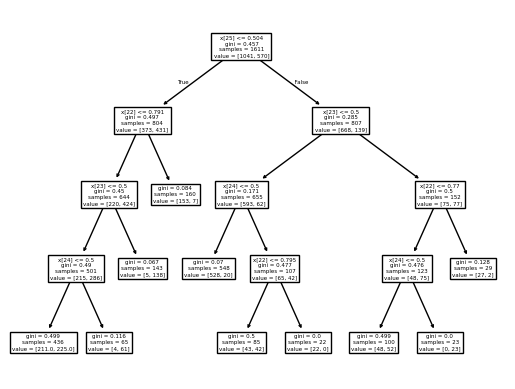

In [36]:
# Visualizing the decision tree to inspect its structure and ensure that there are no unexpected splits
test = pd.read_csv("Data/alzheimer_test.csv")
train = pd.read_csv("Data/alzheimer_train.csv")
X_train, y_train = train.iloc[:, :-1], train.iloc[:, -1]
X_test, y_test = test.iloc[:, :-1], test.iloc[:, -1]
model = DecisionTreeClassifier(ccp_alpha=0.003919,
    max_depth=25,
    min_samples_leaf=21,
    min_samples_split = 58)
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_proba)

plot_tree(model)

[Text(0.5, 0.9, 'x[25] <= 0.504\ngini = 0.457\nsamples = 1611\nvalue = [1041, 570]'),
 Text(0.3076923076923077, 0.7, 'x[22] <= 0.791\ngini = 0.497\nsamples = 804\nvalue = [373, 431]'),
 Text(0.40384615384615385, 0.8, 'True  '),
 Text(0.23076923076923078, 0.5, 'x[23] <= 0.5\ngini = 0.45\nsamples = 644\nvalue = [220, 424]'),
 Text(0.15384615384615385, 0.3, 'x[24] <= 0.5\ngini = 0.49\nsamples = 501\nvalue = [215, 286]'),
 Text(0.07692307692307693, 0.1, 'gini = 0.499\nsamples = 436\nvalue = [211.0, 225.0]'),
 Text(0.23076923076923078, 0.1, 'gini = 0.116\nsamples = 65\nvalue = [4, 61]'),
 Text(0.3076923076923077, 0.3, 'gini = 0.067\nsamples = 143\nvalue = [5, 138]'),
 Text(0.38461538461538464, 0.5, 'gini = 0.084\nsamples = 160\nvalue = [153, 7]'),
 Text(0.6923076923076923, 0.7, 'x[23] <= 0.5\ngini = 0.285\nsamples = 807\nvalue = [668, 139]'),
 Text(0.5961538461538461, 0.8, '  False'),
 Text(0.5384615384615384, 0.5, 'x[24] <= 0.5\ngini = 0.171\nsamples = 655\nvalue = [593, 62]'),
 Text(0.461

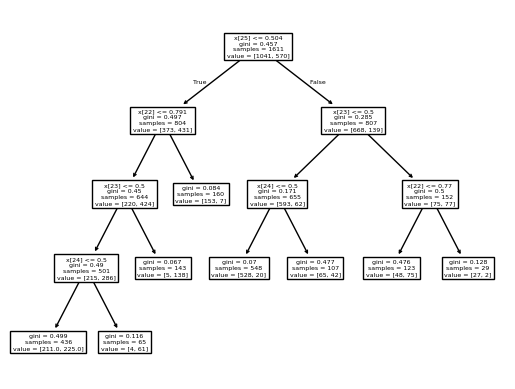

In [37]:
# Visualizing the decision tree to inspect its structure and ensure that there are no unexpected splits
test = pd.read_csv("Data/alzheimer_test.csv")
train = pd.read_csv("Data/alzheimer_train.csv")
X_train, y_train = train.iloc[:, :-1], train.iloc[:, -1]
X_test, y_test = test.iloc[:, :-1], test.iloc[:, -1]
model = DecisionTreeClassifier(ccp_alpha=0.006505,
    max_depth=4,
    min_samples_leaf=25,
    min_samples_split = 15)
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_proba)

plot_tree(model)

In [38]:
results_df

,dataset,params,cv_roc_auc,test_roc_auc
0,heart,"{'ccp_alpha': 0.03745401188473625, 'max_depth'...",0.754117,0.765893
1,heart,"{'ccp_alpha': 0.07796910002727693, 'max_depth'...",0.607314,0.725127
2,heart,"{'ccp_alpha': 0.015599452033620266, 'max_depth...",0.757145,0.765893
3,heart,"{'ccp_alpha': 0.03337086111390219, 'max_depth'...",0.754117,0.765893
4,heart,"{'ccp_alpha': 0.0020584494295802446, 'max_dept...",0.754117,0.765893
...,...,...,...,...
395,alzheimer,"{'ccp_alpha': 0.029529058841893874, 'max_depth...",0.777287,0.753584
396,alzheimer,"{'ccp_alpha': 0.0697015740995268, 'max_depth':...",0.557485,0.500000
397,alzheimer,"{'ccp_alpha': 0.05528199769079078, 'max_depth'...",0.734461,0.753584
398,alzheimer,"{'ccp_alpha': 0.08101133946791808, 'max_depth'...",0.500000,0.500000


In [39]:
# Finding the best hyperparameters for each dataset
best_per_dataset = (
    results_df.sort_values(by=["dataset", "test_roc_auc"], ascending=[True, False]).groupby("dataset", as_index=False).first()
)

params_df = best_per_dataset["params"].apply(pd.Series)

# Finding new set of hyperparameters as a mean from the best results for each dataset
mean_params = params_df.mean()
mean_params_dict = mean_params.to_dict()

# Rounding to integer values
for param in ["max_depth", "min_samples_leaf", "min_samples_split"]:
    mean_params_dict[param] = int(round(mean_params_dict[param]))
mean_results = []

# Training with new hyperparameters on all datasets and evaluating on tests
for name, (train_path, test_path) in datasets.items():
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)

    X_train, y_train = train.iloc[:, :-1], train.iloc[:, -1]
    X_test, y_test = test.iloc[:, :-1], test.iloc[:, -1]

    model = DecisionTreeClassifier(random_state=42, **mean_params_dict)
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    mean_auc = roc_auc_score(y_test, y_proba)

    mean_results.append({
        "dataset": name,
        # Star is a mean from the best 4 sets of hyperparameters from each dataset
        "star_test_roc_auc": mean_auc
    })


In [40]:
# Creating a final dataframe for all of the results

# Splitting all hyperparaemters to separate columns
params_df = results_df['params'].apply(pd.Series)
results_df = pd.concat([results_df.drop('params', axis=1), params_df], axis=1)

results_col = results_df[['cv_roc_auc','test_roc_auc']]
results_df = pd.concat([results_df.drop(['cv_roc_auc','test_roc_auc'],axis=1),results_col], axis=1)

mean_df = pd.DataFrame(mean_results)
results_df = results_df.merge(mean_df, on="dataset")
results_df["diff_from_star"] = results_df["star_test_roc_auc"] - results_df["test_roc_auc"]

In [41]:
mean_df

,dataset,star_test_roc_auc
0,heart,0.768783
1,diabetes,0.784597
2,cancer,0.778981
3,alzheimer,0.866969


In [42]:
results_df

,dataset,ccp_alpha,max_depth,min_samples_leaf,min_samples_split,cv_roc_auc,test_roc_auc,star_test_roc_auc,diff_from_star
0,heart,0.037454,29.0,15.0,44.0,0.754117,0.765893,0.768783,0.002890
1,heart,0.077969,21.0,39.0,59.0,0.607314,0.725127,0.768783,0.043656
2,heart,0.015599,11.0,11.0,25.0,0.757145,0.765893,0.768783,0.002890
3,heart,0.033371,8.0,24.0,4.0,0.754117,0.765893,0.768783,0.002890
4,heart,0.002058,2.0,24.0,45.0,0.754117,0.765893,0.768783,0.002890
...,...,...,...,...,...,...,...,...,...
395,alzheimer,0.029529,26.0,17.0,41.0,0.777287,0.753584,0.866969,0.113385
396,alzheimer,0.069702,11.0,54.0,49.0,0.557485,0.500000,0.866969,0.366969
397,alzheimer,0.055282,10.0,55.0,27.0,0.734461,0.753584,0.866969,0.113385
398,alzheimer,0.081011,25.0,24.0,14.0,0.500000,0.500000,0.866969,0.366969


In [43]:
results_df.to_csv("Results/decisiontree_uniform.csv", index=False)

In [44]:
# Creating a short summary dataset

# Best parameters for each dataset
best_per_dataset = (
    results_df.sort_values(by=["dataset", "test_roc_auc"], ascending=[True, False])
    .groupby("dataset", as_index=False)
    .first()
    .drop(['star_test_roc_auc', 'diff_from_star'], axis=1)
)

# STAR row
mean_row = {
    "dataset": "STAR",
    **mean_params_dict,
    "cv_roc_auc": 0,
    "test_roc_auc": mean_df["star_test_roc_auc"].mean()
}

summary_df = pd.concat([best_per_dataset, pd.DataFrame([mean_row])], ignore_index=True)
summary_df

,dataset,ccp_alpha,max_depth,min_samples_leaf,min_samples_split,cv_roc_auc,test_roc_auc
0,alzheimer,0.006505,4.0,25.0,15.0,0.844899,0.862409
1,cancer,0.000506,14.0,18.0,3.0,0.824355,0.806296
2,diabetes,0.000506,14.0,18.0,3.0,0.785214,0.795224
3,heart,0.006505,4.0,25.0,15.0,0.776140,0.785811
4,STAR,0.003506,9.0,22.0,9.0,0.000000,0.799833


In [45]:
summary_df.to_csv("Results/decisiontree_uniform_summary.csv", index=False)

## 2. Bayesian Optimalization

In [3]:
# Search space for bayesian optimalization
search_spaces = {
    'ccp_alpha': Real(0.0, 0.1, prior='uniform'),
    'max_depth': Integer(1, 30),
    'min_samples_leaf': Integer(1, 60),
    'min_samples_split': Integer(2, 60)
}

In [4]:
all_results_2 = []

for name, (train_path, test_path) in datasets.items():

    # Loading the data
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    X_train, y_train = train.iloc[:, :-1], train.iloc[:, -1]
    X_test, y_test = test.iloc[:, :-1], test.iloc[:, -1]

    # DecisionTreeClassifier Model
    dt = DecisionTreeClassifier(random_state=42)

    # Bayesian search
    bayes_search = BayesSearchCV(
        estimator=dt,
        search_spaces=search_spaces,
        n_iter=100,
        scoring='roc_auc',
        cv=3,
        random_state=42,
        n_jobs=1
    )
    bayes_search.fit(X_train, y_train)

    # Adding the results to a new data frame
    cv_results = pd.DataFrame(bayes_search.cv_results_)

    # Training on test sets
    for i, params in enumerate(bayes_search.cv_results_['params']):
        model = DecisionTreeClassifier(random_state=42, **params)
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]
        test_auc = roc_auc_score(y_test, y_proba)

        # Adding the results
        all_results_2.append({
            "dataset": name,
            "params": params,
            "cv_roc_auc": cv_results.loc[i, 'mean_test_score'],
            "test_roc_auc": test_auc
        })

results_2_df = pd.DataFrame(all_results_2)

In [5]:
# Summary
for dataset in datasets.keys():
    dataset_results = results_2_df[results_2_df['dataset'] == dataset]
    best_idx = dataset_results['test_roc_auc'].idxmax()
    best_result = dataset_results.loc[best_idx]
    
    print(f"\n{dataset.upper()}:")
    print(f"  Best test AUC: {best_result['test_roc_auc']:.4f}")
    print(f"  CV AUC: {best_result['cv_roc_auc']:.4f}")
    print(f"  Parameters: {best_result['params']}")


HEART:
  Best test AUC: 0.7858
  CV AUC: 0.7814
  Parameters: OrderedDict([('ccp_alpha', 0.00559544710023619), ('max_depth', 30), ('min_samples_leaf', 60), ('min_samples_split', 2)])

DIABETES:
  Best test AUC: 0.8332
  CV AUC: 0.7844
  Parameters: OrderedDict([('ccp_alpha', 0.0), ('max_depth', 19), ('min_samples_leaf', 6), ('min_samples_split', 42)])

CANCER:
  Best test AUC: 0.8317
  CV AUC: 0.8334
  Parameters: OrderedDict([('ccp_alpha', 0.00015455386641044516), ('max_depth', 29), ('min_samples_leaf', 52), ('min_samples_split', 57)])

ALZHEIMER:
  Best test AUC: 0.8679
  CV AUC: 0.8506
  Parameters: OrderedDict([('ccp_alpha', 0.001422950087408069), ('max_depth', 25), ('min_samples_leaf', 23), ('min_samples_split', 60)])


In [6]:
# Finding the best hyperparameters for each dataset
best_per_dataset_2 = (
    results_2_df.sort_values(by=["dataset", "test_roc_auc"], ascending=[True, False]).groupby("dataset", as_index=False).first()
)

params_2_df = best_per_dataset_2["params"].apply(pd.Series)

# Finding new set of hyperparameters as a mean from the best results for each dataset
mean_params_2 = params_2_df.mean()
mean_params_dict_2 = mean_params_2.to_dict()

# Rounding to integer values
for param in ["max_depth", "min_samples_leaf", "min_samples_split"]:
    mean_params_dict_2[param] = int(round(mean_params_dict_2[param]))
mean_results_2 = []

# Training with new hyperparameters on all datasets and evaluating on tests
for name, (train_path, test_path) in datasets.items():
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)

    X_train, y_train = train.iloc[:, :-1], train.iloc[:, -1]
    X_test, y_test = test.iloc[:, :-1], test.iloc[:, -1]

    model = DecisionTreeClassifier(random_state=42, **mean_params_dict_2)
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    mean_auc = roc_auc_score(y_test, y_proba)

    mean_results_2.append({
        "dataset": name,
        # Star is a mean from the best 4 sets of hyperparameters from each dataset
        "star_test_roc_auc": mean_auc
    })


In [7]:
# Creating a final dataframe for all of the results

# Splitting all hyperparaemters to separate columns
params_2_df = results_2_df['params'].apply(pd.Series)
results_2_df = pd.concat([results_2_df.drop('params', axis=1), params_2_df], axis=1)

results_col_2 = results_2_df[['cv_roc_auc','test_roc_auc']]
results_2_df = pd.concat([results_2_df.drop(['cv_roc_auc','test_roc_auc'],axis=1),results_col_2], axis=1)

mean_2_df = pd.DataFrame(mean_results_2)
results_2_df = results_2_df.merge(mean_2_df, on="dataset")
results_2_df["diff_from_star"] = results_2_df["star_test_roc_auc"] - results_2_df["test_roc_auc"]

In [8]:
results_2_df.to_csv("Results/decisiontree_bayes.csv", index=False)

In [9]:
# Best parameters for each dataset
best_per_dataset_2 = (
    results_2_df.sort_values(by=["dataset", "test_roc_auc"], ascending=[True, False])
    .groupby("dataset", as_index=False)
    .first()
    .drop(['star_test_roc_auc', 'diff_from_star'], axis=1)
)

# STAR row
mean_row_2 = {
    "dataset": "STAR",
    **mean_params_dict_2,
    "cv_roc_auc": 0,
    "test_roc_auc": mean_2_df["star_test_roc_auc"].mean()
}

summary_2_df = pd.concat([best_per_dataset_2, pd.DataFrame([mean_row_2])], ignore_index=True)

In [10]:
summary_2_df.to_csv("Results/decisiontree_bayes_summary.csv", index=False)

In [11]:
summary_2_df

,dataset,ccp_alpha,max_depth,min_samples_leaf,min_samples_split,cv_roc_auc,test_roc_auc
0,alzheimer,0.001423,25.0,23.0,60.0,0.850586,0.867869
1,cancer,0.000155,29.0,52.0,57.0,0.833440,0.831729
2,diabetes,0.000000,19.0,6.0,42.0,0.784378,0.833194
3,heart,0.005595,30.0,60.0,2.0,0.781351,0.785811
4,STAR,0.001793,26.0,35.0,40.0,0.000000,0.795328
